In [1]:
import sys, os

# Phải set TRƯỚC khi import torch
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.chdir('d:/TPV project/OCR_HVKS/deepdoc_vietocr')
sys.path.insert(0, 'd:/TPV project/OCR_HVKS/deepdoc_vietocr')

import torch
import numpy as np
from PIL import Image
import fitz
from IPython.display import display
import time

print('CUDA:', torch.cuda.is_available(), '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')

import onnxruntime as ort
print('ONNX providers:', ort.get_available_providers())

print('Loading OCR...')
from module.ocr import OCR
ocr = OCR()
print('OK')

CUDA: True | NVIDIA GeForce GTX 1650
ONNX providers: ['DmlExecutionProvider', 'CPUExecutionProvider']
Loading OCR...


c:\Users\ASUS\ai_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ASUS\ai_env\Lib\site-packages\gdown\__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


OK


Tổng trang: 8
Trang 2 | (2492, 3522)


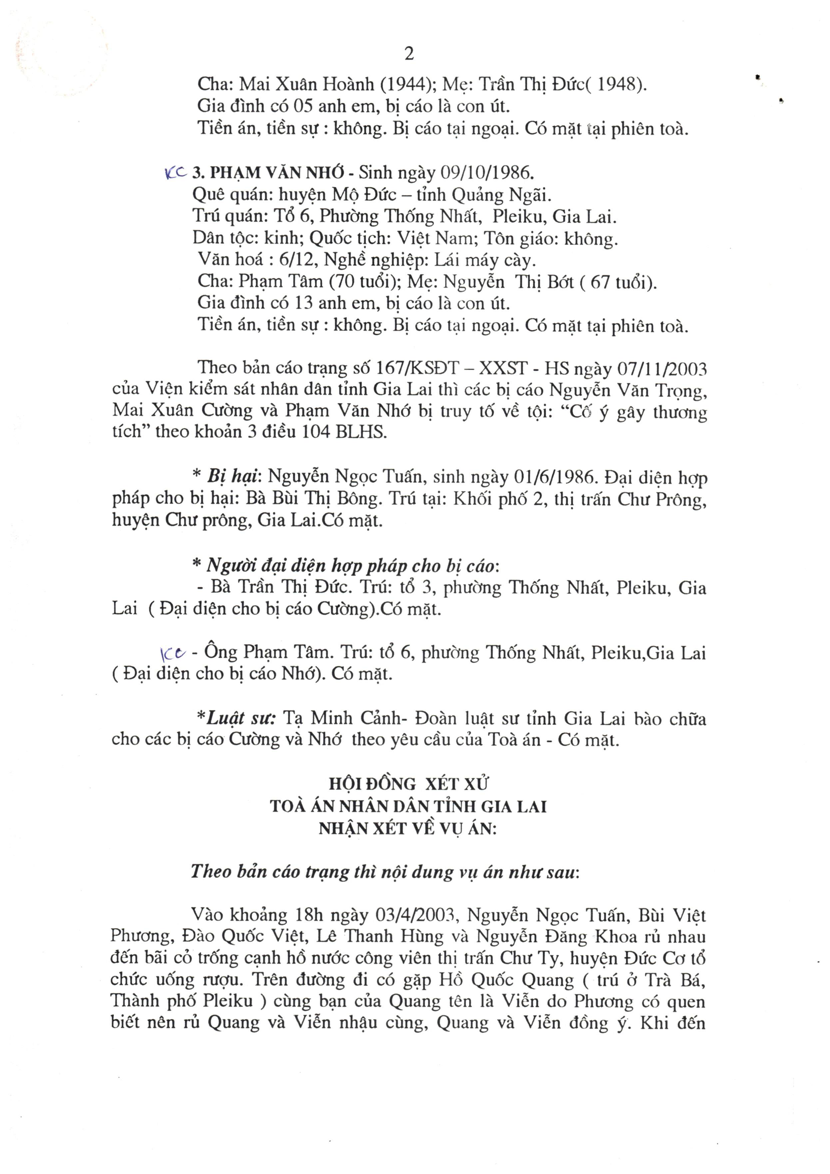

In [2]:
PDF_PATH = r'C:\Users\ASUS\Downloads\HSVKS\BA.12.2004.HS-ST.NGUYEN VAN TRONG-MAI XUAN CUONG-PHAM VAN NHO\BA_CHINH_NGUYEN VAN TRONG-MAI XUAN CUONG-PHAM VAN NHO.pdf'
PAGE_INDEX = 1  # 0-based

doc = fitz.open(PDF_PATH)
print(f'Tổng trang: {len(doc)}')

page = doc[PAGE_INDEX]
mat = fitz.Matrix(300/72, 300/72)
pix = page.get_pixmap(matrix=mat)
img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
doc.close()

print(f'Trang {PAGE_INDEX+1} | {img.size}')
display(img.resize((img.width//3, img.height//3)))

Tổng số trang: 8
Trang 1 | Kích thước: (2492, 3529)


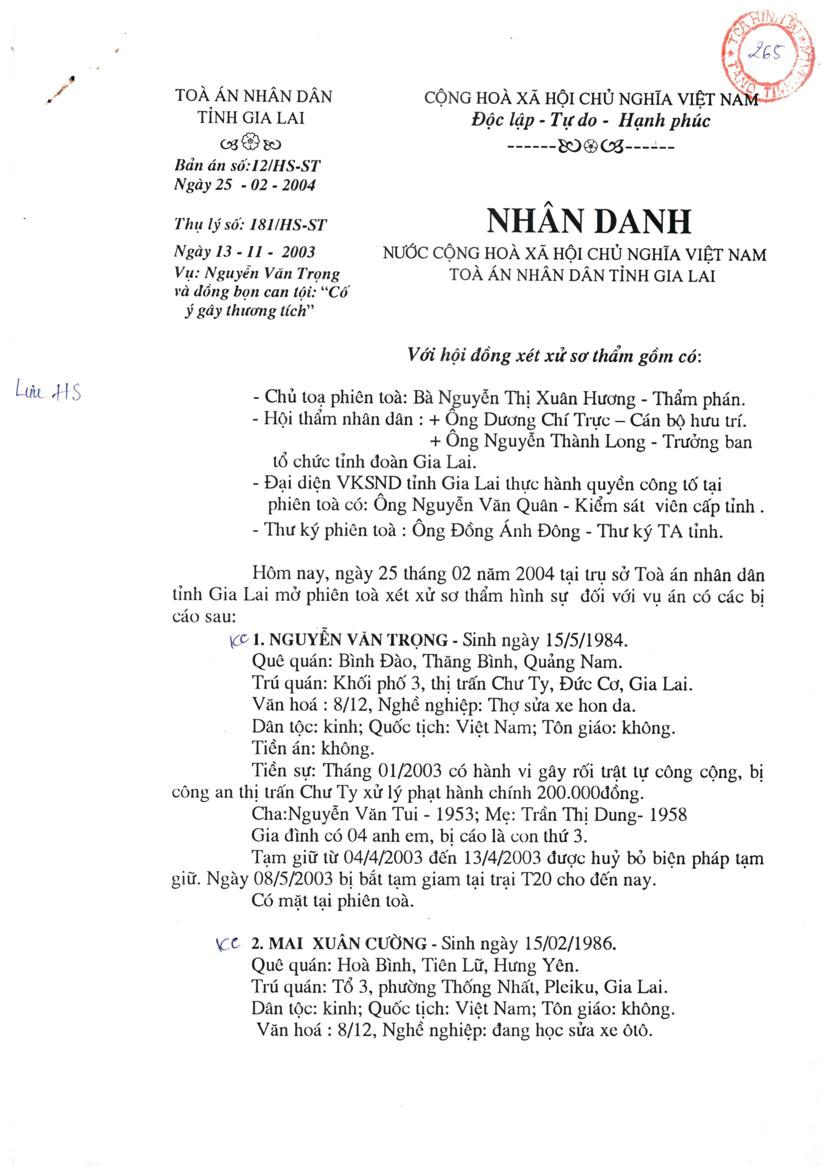

In [3]:
PDF_PATH = r'C:\Users\ASUS\Downloads\HSVKS\BA.12.2004.HS-ST.NGUYEN VAN TRONG-MAI XUAN CUONG-PHAM VAN NHO\BA_CHINH_NGUYEN VAN TRONG-MAI XUAN CUONG-PHAM VAN NHO.pdf'
PAGE_INDEX = 0  # đổi số trang ở đây (0-based)

doc = fitz.open(PDF_PATH)
print(f'Tổng số trang: {len(doc)}')

page = doc[PAGE_INDEX]
mat = fitz.Matrix(300/72, 300/72)
pix = page.get_pixmap(matrix=mat)
img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)

print(f'Trang {PAGE_INDEX + 1} | Kích thước: {img.size}')
display(img.resize((img.width // 3, img.height // 3)))  # preview thu nhỏ

In [4]:
import time

t0 = time.time()
result = ocr(np.array(img))
elapsed = time.time() - t0

print(f'Thời gian OCR: {elapsed:.2f}s | Số dòng: {len(result)}')
print('=' * 60)
for box, (text, conf) in result:
    x0, y0 = box[0]
    x1, y1 = box[2]
    flag = '⚠' if conf < 0.9 else ''
    print(f'[{conf:.2f}] ({int(x0)},{int(y0)},{int(x1)},{int(y1)}) {text} {flag}')

Thời gian OCR: 2.59s | Số dòng: 46
[1.00] (519,246,1009,320) TOÀ ÁN NHÂN DÂN 
[1.00] (1276,261,2288,323) CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM 
[1.00] (587,308,922,390) TỈNH GIA LAI 
[1.00] (1413,331,2136,393) Độc lập - Tự do - Hạnh phúc 
[1.00] (653,390,853,467) BD 
[1.00] (1632,412,2002,463) - WORT 
[1.00] (519,467,968,529) Bản án số:12/HS-ST 
[1.00] (515,526,960,588) Ngày 25 - 02-2004 
[1.00] (1455,599,2083,710) NHÂN DANH 
[1.00] (519,643,990,706) Thụ lý số: 181/HS-ST 
[1.00] (519,724,953,787) Ngày 13 - 11 - 2003 
[1.00] (1139,717,2314,798) NƯỚC CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM 
[1.00] (516,787,1027,857) Vụ: Nguyễn Văn Trọng 
[1.00] (1343,786,2154,860) TOÀ ÁN NHÂN DÂN TỈNH GIA LAI 
[1.00] (516,842,1053,908) và đồng bọn can tội: ? Cố 
[1.00] (545,904,946,967) ý gây thương tích? 
[1.00] (1217,1025,2113,1107) Với hội đồng xét xử sơ thẩm gồm có: 
[1.00] (34,1119,251,1219) LƯU HS 
[1.00] (753,1150,2239,1235) - Chủ toạ phiên toà: Bà Nguyễn Thị Xuân Hương - Thẩm phán. 
[1.00] (746,1217,2247

In [5]:
# Xem toàn bộ text ghép lại (không có bbox)
full_text = '\n'.join([text for _, (text, _) in result])
print(full_text)

TOÀ ÁN NHÂN DÂN
CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM
TỈNH GIA LAI
Độc lập - Tự do - Hạnh phúc
BD
- WORT
Bản án số:12/HS-ST
Ngày 25 - 02-2004
NHÂN DANH
Thụ lý số: 181/HS-ST
Ngày 13 - 11 - 2003
NƯỚC CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM
Vụ: Nguyễn Văn Trọng
TOÀ ÁN NHÂN DÂN TỈNH GIA LAI
và đồng bọn can tội: ? Cố
ý gây thương tích?
Với hội đồng xét xử sơ thẩm gồm có:
LƯU HS
- Chủ toạ phiên toà: Bà Nguyễn Thị Xuân Hương - Thẩm phán.
Hội thẩm nhân dân: + nn ba ngường chí trực ? cán bộ hưu trí
+ Ông Nguyễn Thành Long - Trưởng ban
tổ chức tỉnh đoàn Gia Lai.
Đại diện VKSND tỉnh Gia Lai thực hành quyền công tố tại
phiên toà có: Ông Nguyễn Văn Quân - Kiểm sát viên cấp tỉnh
- Thư ký phiên toà: Ông Đồng Ánh Đý TA tỉnh.
Hôm nay, ngày 25 tháng 02 năm 2004 tại trụ sở Toà án nhân dân
tỉnh Gia Lai mở phiên toà xét xử sơ thẩm hình sự đối với vụ án có các bị
cáo sau:
ICC..NGUYỄN VĂN TRỌNG - SINH NGÀY 15/5/1984.
Quê quán: Bình Đào, Thăng Bình, Quảng Nam
Trú quán: Khối phố 3, thị trấn Chư Ty, Đức Cơ, Gia Lai.
Vă

In [6]:
# OCR toàn bộ PDF, in từng trang
doc = fitz.open(PDF_PATH)

all_pages_text = []
for i, page in enumerate(doc):
    mat = fitz.Matrix(300/72, 300/72)
    pix = page.get_pixmap(matrix=mat)
    img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)

    t0 = time.time()
    result = ocr(np.array(img))
    elapsed = time.time() - t0

    page_text = '\n'.join([text for _, (text, _) in result])
    all_pages_text.append(page_text)

    print(f'--- Trang {i+1} ({elapsed:.1f}s) ---')
    print(page_text[:])  # preview 300 ký tự đầu
    print()

doc.close()
print(f'Xong! Tổng {len(all_pages_text)} trang')

--- Trang 1 (1.8s) ---
TOÀ ÁN NHÂN DÂN
CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM
TỈNH GIA LAI
Độc lập - Tự do - Hạnh phúc
BD
- WORT
Bản án số:12/HS-ST
Ngày 25 - 02-2004
NHÂN DANH
Thụ lý số: 181/HS-ST
Ngày 13 - 11 - 2003
NƯỚC CỘNG HOÀ XÃ HỘI CHỦ NGHĨA VIỆT NAM
Vụ: Nguyễn Văn Trọng
TOÀ ÁN NHÂN DÂN TỈNH GIA LAI
và đồng bọn can tội: ? Cố
ý gây thương tích?
Với hội đồng xét xử sơ thẩm gồm có:
LƯU HS
- Chủ toạ phiên toà: Bà Nguyễn Thị Xuân Hương - Thẩm phán.
Hội thẩm nhân dân: + nn ba ngường chí trực ? cán bộ hưu trí
+ Ông Nguyễn Thành Long - Trưởng ban
tổ chức tỉnh đoàn Gia Lai.
Đại diện VKSND tỉnh Gia Lai thực hành quyền công tố tại
phiên toà có: Ông Nguyễn Văn Quân - Kiểm sát viên cấp tỉnh
- Thư ký phiên toà: Ông Đồng Ánh Đý TA tỉnh.
Hôm nay, ngày 25 tháng 02 năm 2004 tại trụ sở Toà án nhân dân
tỉnh Gia Lai mở phiên toà xét xử sơ thẩm hình sự đối với vụ án có các bị
cáo sau:
ICC..NGUYỄN VĂN TRỌNG - SINH NGÀY 15/5/1984.
Quê quán: Bình Đào, Thăng Bình, Quảng Nam
Trú quán: Khối phố 3, thị trấn Chư 